<a href="https://colab.research.google.com/github/Saruul-hash/Saru/blob/main/lab2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
"""Task2: Анализ тональности с помощью keras

Бүрэн шийдэл: суурь түвшин (7 оноо) + ахисан түвшний 3 нэмэлт функц
"""
# Судалгааны үр дүнг тогтвортой байлгахын тулд random seed тохируулах
np.random.seed(42)  # Утасны утсыг тохируулах
keras.utils.set_random_seed(42)  # Keras-ийн утсыг тохируулах

print("ДААЛГАВАР 2: АНАЛИЗ ТОНАЛЬНОСТИ С ПОМОЩЬЮ KERAS")

# ШАГ 1: ДАННЫ БЭЛТГЭХ
print("\n ШАГ 1: ДАННЫ БЭЛТГЭХ")

sentiment_data = {
    "text": [
        # --- позитив (1) ---
        "Отличный фильм, очень понравился!",  # Эерэг текст
        "Прекрасная книга, рекомендую всем прочитать.",  # Эерэг текст
        "Качественный товар, доволен покупкой.",  # Эерэг текст
        "Замечательный сервис, быстро и профессионально.",  # Эерэг текст
        "Потрясающий ресторан, вкусная еда и уютная атмосфера.",  # Эерэг текст
        "Великолепный спектакль, получил массу удовольствия.",  # Эерэг текст
        "Отличное приложение, удобный интерфейс.",  # Эерэг текст
        "Прекрасный отель, комфортные номера и хороший завтрак.",  # Эерэг текст
        "Замечательный преподаватель, интересные лекции.",  # Эерэг текст
        "Потрясающая музыка, слушаю постоянно.",  # Эерэг текст
        "Отличный телефон, все работает быстро.",  # Эерэг текст
        "Прекрасный подарок, очень доволен.",  # Эерэг текст
        "Качественный кофе, ароматный и вкусный.",  # Эерэг текст
        "Замечательный парк, красивая природа.",  # Эерэг текст
        "Потрясающий концерт, незабываемые эмоции.",  # Эерэг текст
        # --- негатив (0) ---
        "Ужасный фильм, полная потеря времени.",  # Сөрөг текст
        "Плохая книга, скучно и неинтересно.",  # Сөрөг текст
        "Низкое качество товара, очень разочарован.",  # Сөрөг текст
        "Плохой сервис, долго ждал и ничего не получил.",  # Сөрөг текст
        "Отвратительный ресторан, невкусная еда.",  # Сөрөг текст
        "Скучный спектакль, не рекомендую.",  # Сөрөг текст
        "Плохое приложение, постоянно глючит.",  # Сөрөг текст
        "Ужасный отель, грязные номера и плохое обслуживание.",  # Сөрөг текст
        "Скучный преподаватель, неинтересные лекции.",  # Сөрөг текст
        "Плохая музыка, не понравилась.",  # Сөрөг текст
        "Плохой телефон, постоянно зависает.",  # Сөрөг текст
        "Разочаровался в подарке, не то что ожидал.",  # Сөрөг текст
        "Плохой кофе, безвкусный и холодный.",  # Сөрөг текст
        "Запущенный парк, грязно и неухоженно.",  # Сөрөг текст
        "Скучный концерт, не оправдал ожиданий.",  # Сөрөг текст
        # --- нейтрал (2) ---
        "Обычный фильм, ничего особенного.",  # Нейтрал текст
        "Стандартная книга, читается нормально.",  # Нейтрал текст
        "Обычный товар, соответствует описанию.",  # Нейтрал текст
        "Нормальный сервис, без особых претензий.",  # Нейтрал текст
        "Обычный ресторан, стандартное меню.",  # Нейтрал текст
        "Средний спектакль, можно посмотреть.",  # Нейтрал текст
        "Обычное приложение, работает как надо.",  # Нейтрал текст
        "Стандартный отель, без изысков.",  # Нейтрал текст
        "Обычный преподаватель, стандартные лекции.",  # Нейтрал текст
        "Средняя музыка, ничего особенного.",  # Нейтрал текст
    ],
    "sentiment": [
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,  # Эерэг
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,  # Сөрөг
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2,  # Нейтрал
    ]
}

df = pd.DataFrame(sentiment_data)  # DataFrame-г үүсгэж байна.

print(f" Нийт отзыв: {len(df)}")  # Нийт сэтгэгдлийг хэвлэх
print(f" Ангилалын хуваарилалт:")  # Ангилалын хуваарилалтыг хэвлэх
class_counts = df["sentiment"].value_counts().sort_index()  # Ангиллын тоог тоолох
class_names = {0: "негатив", 1: "позитив", 2: "нейтрал"}  # Ангиллаас нэрүүдийг тодорхойлох
for k, v in class_counts.items():  # Ангилалын тоог хэвлэх
    print(f"   {class_names[k]}: {v}")  # Ангилалын нэр болон тоо

ДААЛГАВАР 2: АНАЛИЗ ТОНАЛЬНОСТИ С ПОМОЩЬЮ KERAS

 ШАГ 1: ДАННЫ БЭЛТГЭХ
 Нийт отзыв: 40
 Ангилалын хуваарилалт:
   негатив: 15
   позитив: 15
   нейтрал: 10


In [4]:
# ШАГ 2: ВЕКТОРИЗАЦИЯ TF-IDF “Выполняется векторизация TF-IDF и разделение данных на обучающую и тестовую выборки.
print("\n ШАГ 2: TF-IDF ВЕКТОРИЗАЦИЯ")  # TF-IDF векторчлолын шат

# Бинар классификацийн өгөгдөл (позитив/негатив)
df_binary = df[df["sentiment"] != 2].copy()  # Нейтрал текстийг хасах

# TF-IDF векторчлогч
vectorizer = TfidfVectorizer(
    max_features=100,  # Векторчилж авах онцлогийн хамгийн их тоо
    ngram_range=(1, 2),  # Нэг ба хоёр бүтэн жишээ (n-граммы)
    min_df=1,  # Меньш ніж 1 раз, тооноос багасгах
    stop_words=None  # Зогсоох үгсийг тодорхойлохгүй
)

X = vectorizer.fit_transform(df_binary["text"]).toarray()  # Текстийг TF-IDF векторчилж байна
y = df_binary["sentiment"].values  # Тональ байдлын хариу утгуудыг авч байна

print(f" TF-IDF-ийн дараах хэмжээс: {X.shape}")  # TF-IDF векторын хэмжээг хэвлэх
print(f" Толь бичгийн хэмжээ: {len(vectorizer.get_feature_names_out())}")  # Онцлогийн нийт тоог хэвлэх
print(f" Ангилал: позитив={np.sum(y==1)}, негатив={np.sum(y==0)}")  # Ангиллын тоо

# Train/test хуваалт
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y  # Сургалт, тестийн багц хуваалт
)

# Стандартчилал (StandardScaler) - нейрон сүлжээний сургалтыг түргэтгэнэ
scaler = StandardScaler()  # Стандартчиллын обьект
X_train_scaled = scaler.fit_transform(X_train)  # Сургалтын өгөгдлийг стандартчилах
X_test_scaled = scaler.transform(X_test)  # Тестийн өгөгдлийг стандартчилах

print(f" Сургалтын өгөгдөл: {X_train_scaled.shape[0]} жишээ, {X_train_scaled.shape[1]} онцлог")  # Сургалтын жишээ тоо
print(f" Тестийн өгөгдөл: {X_test_scaled.shape[0]} жишээ")  # Тестийн жишээ тоо хэвлэх


 ШАГ 2: TF-IDF ВЕКТОРИЗАЦИЯ
 TF-IDF-ийн дараах хэмжээс: (30, 100)
 Толь бичгийн хэмжээ: 100
 Ангилал: позитив=15, негатив=15
 Сургалтын өгөгдөл: 21 жишээ, 100 онцлог
 Тестийн өгөгдөл: 9 жишээ


In [5]:
# ШАГ 3: МОДЕЛЬ БАЙГУУЛАХ (Суурь түвшин) "Код предназначен для создания базовой модели нейронной сети и обучения."
print("\n ШАГ 3: НЕЙРОН СҮЛЖЭЭ БАЙГУУЛАХ")  # Нейрон сүлжээний архитектурын үүсгэх шат

# ---------- Модель 1: Суурь архитектур ----------
def build_baseline_model(input_dim):
    """Суурь архитектур: 2 Dense давхарга"""  # Суурь архитектурын тодорхойлолт
    model = keras.Sequential([  # Keras-с дараалсан загварыг үүсгэнэ
        layers.Dense(32, activation="relu", input_shape=(input_dim,)),  # Нэгдүгээр давхарга: 32 н mask тэй, ReLU идэвхжүүлэгч
        layers.Dense(16, activation="relu"),  # Хоёрдугаар давхарга: 16 н mask тэй, ReLU идэвхжүүлэгч
        layers.Dense(1, activation="sigmoid"),  # Гуравдугаар давхарга: 1 н mask тэй, Sigmoid идэвхжүүлэгч, бинар ангилалд зориулагдсан
    ])
    return model  # Загварыг буцаана

# Модель байгуулах
baseline_model = build_baseline_model(X_train_scaled.shape[1])  # Сургалтын өгөгдлийн онцлогийн тоо

baseline_model.compile(
    optimizer="adam",  # Adam оптимизатор
    loss="binary_crossentropy",  # Бинар ангиллын алдаа (loss) функц
    metrics=["accuracy"]  # Гүйцэтгэлийг хэмжих (metrics)
)

print("\n Суурь моделийн бүтэц:")  # Моделийн бүтэц хэвлэх
baseline_model.summary()  # Загварын бүх давхарга, параметрийн тоог дэлгэцлэнэ

# Сургалт
print("\n Сургалт эхэлж байна...")  # Сургалтыг эхлүүлэх мэдээлэл
history_baseline = baseline_model.fit(
    X_train_scaled, y_train,  # Сургалтын өгөгдөл
    epochs=80,  # Сургалт явуулах удаа
    batch_size=8,  # Багцын хэмжээ
    validation_split=0.2,  # Валидацийн өгөгдөлд 20% хуваарилах
    verbose=1,  # Сургалтын явцыг дэлгэцлэнэ
)


 ШАГ 3: НЕЙРОН СҮЛЖЭЭ БАЙГУУЛАХ


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 Суурь моделийн бүтэц:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)


 Сургалт эхэлж байна...
Epoch 1/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 705ms/step - accuracy: 0.3125 - loss: 0.7532 - val_accuracy: 0.2000 - val_loss: 0.9029
Epoch 2/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.3750 - loss: 0.7054 - val_accuracy: 0.2000 - val_loss: 0.9053
Epoch 3/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.5000 - loss: 0.6663 - val_accuracy: 0.2000 - val_loss: 0.9074
Epoch 4/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.5000 - loss: 0.6311 - val_accuracy: 0.2000 - val_loss: 0.9093
Epoch 5/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.6250 - loss: 0.5985 - val_accuracy: 0.2000 - val_loss: 0.9113
Epoch 6/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.6875 - loss: 0.5697 - val_accuracy: 0.2000 - val_loss: 0.9129
Epoch 7/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.7500 - loss: 0.5439 - val_accuracy: 0.2000 - val_loss: 0.9146
Epoch 8/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8125 - loss: 0.5185 - val_acc

In [6]:
# ШАГ 4: МЕТРИКҮҮД БА ҮНЭЛГЭЭ "Код содержит функции для оценки производительности модели, расчета F1-скор, Precision, Recall и генерации отчета по классификации.
print("\n ШАГ 4: ҮНЭЛГЭЭ")  # Метркийг тооцоолох болон үнэлгээ авах шат

# Предсказалт хийх
y_pred_binary = (baseline_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()  # Тестийн өгөгдлийг предсказлах, 0.5-ээс их зүйлсийг 1 (позитив), бусдыг 0 (негатив) гэж ангилна

# Метрикууд
f1 = f1_score(y_test, y_pred_binary)  # F1-скорийг тооцоолно
prec = precision_score(y_test, y_pred_binary)  # Precision-ийн утгыг тооцоолно
rec = recall_score(y_test, y_pred_binary)  # Recall-ийн утгыг тооцоолно

print(" Суурь моделийн метрикууд:")  # Метркийг хэвлэх
print(f"   F1-score:  {f1:.4f}")  # F1-score
print(f"   Precision: {prec:.4f}")  # Precision
print(f"   Recall:    {rec:.4f}")  # Recall

print("\ Дэлгэрэнгүй тайлан:")  # Дэлгэрэнгүй тайлан гаргахад бэлтгэж байна
print(classification_report(y_test, y_pred_binary, target_names=["негатив", "позитив"]))  # Ангилалын эмхэтгэл, классыг нэрлэж хэвлэх

<>:17: SyntaxWarning: invalid escape sequence '\ '
<>:17: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_23231/1335325866.py:17: SyntaxWarning: invalid escape sequence '\ '
  print("\ Дэлгэрэнгүй тайлан:")  # Дэлгэрэнгүй тайлан гаргахад бэлтгэж байна



 ШАГ 4: ҮНЭЛГЭЭ
 Суурь моделийн метрикууд:
   F1-score:  0.2500
   Precision: 0.2500
   Recall:    0.2500
\ Дэлгэрэнгүй тайлан:
              precision    recall  f1-score   support

     негатив       0.40      0.40      0.40         5
     позитив       0.25      0.25      0.25         4

    accuracy                           0.33         9
   macro avg       0.33      0.33      0.33         9
weighted avg       0.33      0.33      0.33         9




 ШАГ 5: ГРАФИКҮҮД


/tmp/ipykernel_23231/3048581141.py:24: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # Графикуудын зайг сайжруулж байна
/tmp/ipykernel_23231/3048581141.py:25: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')  # Графикийг png форматаар хадгалах
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


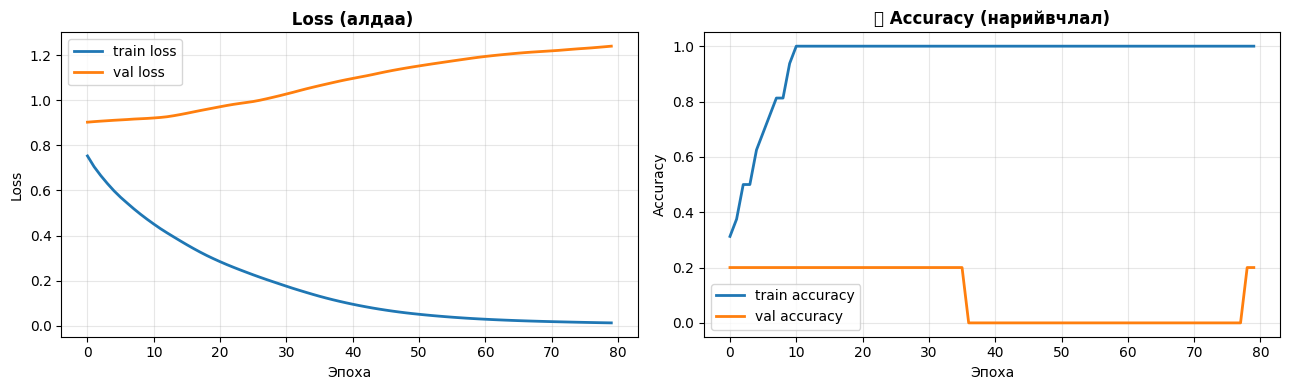

In [7]:
# ШАГ 5: ГРАФИКҮҮД "Код предназначен для визуализации графиков 'loss' и 'accuracy', возникших в процессе обучения, и представления их в понятном для пользователей виде."
print("\n ШАГ 5: ГРАФИКҮҮД")  # График дүрслэх шат

fig, axes = plt.subplots(1, 2, figsize=(13, 4))  # Графикуудыг нэг мөрөнд 2 баганаар зохион байгуулна

# Loss график
axes[0].plot(history_baseline.history["loss"], label="train loss", linewidth=2)  # Сургалтын алдааны (loss) график
axes[0].plot(history_baseline.history["val_loss"], label="val loss", linewidth=2)  # Валидацийн алдааны график
axes[0].set_title(" Loss (алдаа)", fontsize=12, fontweight='bold')  # Графикын гарчиг
axes[0].set_xlabel("Эпоха")  # X-axis шошго
axes[0].set_ylabel("Loss")  # Y-axis шошго
axes[0].legend()  # Тэмдэглэлийг гаргана
axes[0].grid(alpha=0.3)  # Сул шугамуудыг үргэлжлүүлэн дүрслэнэ

# Accuracy график
axes[1].plot(history_baseline.history["accuracy"], label="train accuracy", linewidth=2)  # Сургалтын нарийвчлалын график
axes[1].plot(history_baseline.history["val_accuracy"], label="val accuracy", linewidth=2)  # Валидацийн нарийвчлалын график
axes[1].set_title("📈 Accuracy (нарийвчлал)", fontsize=12, fontweight='bold')  # Графикын гарчиг
axes[1].set_xlabel("Эпоха")  # X-axis шошго
axes[1].set_ylabel("Accuracy")  # Y-axis шошго
axes[1].legend()  # Тэмдэглэлийг гаргана
axes[1].grid(alpha=0.3)  # Сул шугамуудыг үргэлжлүүлэн дүрслэнэ

plt.tight_layout()  # Графикуудын зайг сайжруулж байна
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')  # Графикийг png форматаар хадгалах
plt.show()  # Графикийг дэлгэцэнд харуулах

In [8]:
# НЭМЭЛТ 1: DROPOUT + EARLY STOPPING
print(" НЭМЭЛТ 1: DROPOUT + EARLY STOPPING")  # Dropout болон Early Stopping-ийг ашиглах

def build_model_with_dropout(input_dim):
    """Dropout-тай модель - overfitting-ээс сэргийлнэ"""  # Dropout загварыг тодорхойлох
    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(input_dim,)),  # 64 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dropout(0.3),  # 30% нейронуудыг унтрааж байна
        layers.Dense(32, activation="relu"),  # 32 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dropout(0.3),  # Дахин 30% нейронуудыг унтрааж байна
        layers.Dense(16, activation="relu"),  # 16 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dense(1, activation="sigmoid"),  # 1 н mask тэй, Sigmoid идэвхжүүлэгч
    ])
    return model  # Загварыг буцаана

# Өгөгдлөөр загварыг байгуулах
model_dropout = build_model_with_dropout(X_train_scaled.shape[1])

model_dropout.compile(
    optimizer="adam",  # Adam оптимизатор
    loss="binary_crossentropy",  # Бинар ангиллын алдаа (loss)
    metrics=["accuracy"]  # Гүйцэтгэлийг хэмжих
)

# Early Stopping - val_loss сайжрахгүй бол сургалтыг зогсооно
early_stop = EarlyStopping(
    monitor='val_loss',  # Валидацийн алдааг хянах
    patience=10,  # Сургалт үргэлжлэх хугацаа
    restore_best_weights=True,  # Шилдэг жинтэй загварыг буцаана
    verbose=1  # Үнэлгээний явцыг дэлгэцэнд харуулах
)

print(" Dropout + Early Stopping моделийн бүтэц:")  # Моделийн бүтэц хэвлэх
model_dropout.summary()  # Загварын давхаргын мэдээлэл гаргах

# Загварыг сургалтанд оруулах
history_dropout = model_dropout.fit(
    X_train_scaled, y_train,
    epochs=100,  # Сургалт явуулах удаа
    batch_size=8,  # Багцын хэмжээ
    validation_split=0.2,  # Валидацийн өгөгдөл хуваарилах
    callbacks=[early_stop],  # EarlyStopping callback
    verbose=1,  # Сургалтын явцыг дэлгэцэнд харуулах
)

# Метрикууд
y_pred_dropout = (model_dropout.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()  # Тестийн өгөгдлийг предсказлах
f1_drop = f1_score(y_test, y_pred_dropout)  # F1-скорыг тооцоолоход
prec_drop = precision_score(y_test, y_pred_dropout)  # Precision-ийг тооцоолоход
rec_drop = recall_score(y_test, y_pred_dropout)  # Recall-ийг тооцоолоход

print("\n Dropout моделийн метрикууд:")  # Метрикийг хэвлэх
print(f"   F1-score:  {f1_drop:.4f}")  # F1-score
print(f"   Precision: {prec_drop:.4f}")  # Precision
print(f"   Recall:    {rec_drop:.4f}")  # Recall

 НЭМЭЛТ 1: DROPOUT + EARLY STOPPING
 Dropout + Early Stopping моделийн бүтэц:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 243ms/step - accuracy: 0.4375 - loss: 0.7715 - val_accuracy: 0.4000 - val_loss: 0.6125
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6250 - loss: 0.7297 - val_accuracy: 0.4000 - val_loss: 0.6168
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3750 - loss: 0.8218 - val_accuracy: 0.4000 - val_loss: 0.6176
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4375 - loss: 0.7662 - val_accuracy: 0.4000 - val_loss: 0.6186
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4375 - loss: 0.7201 - val_accuracy: 0.6000 - val_loss: 0.6186
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5625 - loss: 0.6478 - val_accuracy: 0.6000 - val_loss: 0.6182
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5625 - loss: 0.6623 - val_accuracy: 0.6000 - val_loss: 0.6178
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5625 - loss: 0.6726 - val_accuracy: 0.6000 - val_loss

In [9]:
# НЭМЭЛТ 2: МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ (3 КЛАСС)
print(" НЭМЭЛТ 2: МУЛЬТИКЛАСС КЛАССИФИКАЦИЯ (3 КЛАСС)")  # Мультикласс ангилах зорилготой код

# Бүх 3 ангилалтай өгөгдөл бэлтгэх
X_all = vectorizer.fit_transform(df["text"]).toarray()  # Бүх текстийг TF-IDF векторчлох
y_all = df["sentiment"].values  # Ангилалын утгуудыг авах

# LabelEncoder - ангилалуудыг one-hot encoding-д бэлтгэх
label_encoder = LabelEncoder()  # LabelEncoder обьект үүсгэх
y_all_encoded = label_encoder.fit_transform(y_all)  # Ангилалын утгуудыг (0, 1, 2) давхцахгүй нэгж утгат хуваарилах

# Train/test хуваалт
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all_encoded, test_size=0.3, random_state=42, stratify=y_all_encoded  # Сургалт, тестийн бүлэгт хуваах
)

# Стандартчилал
X_train_all_scaled = scaler.fit_transform(X_train_all)  # Сургалтын өгөгдлийг стандартчилах
X_test_all_scaled = scaler.transform(X_test_all)  # Тестийн өгөгдлийг стандартчилах

# 3 ангиллын мультикласс модель
def build_multiclass_model(input_dim, num_classes=3):
    """Мультикласс классификацийн модель"""  # Мультиклассын загварын тодорхойлолт
    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(input_dim,)),  # 64 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dropout(0.3),  # 30% нейронуудыг унтраах
        layers.Dense(32, activation="relu"),  # 32 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dropout(0.3),  # Дахин 30% нейронуудыг унтраах
        layers.Dense(num_classes, activation="softmax"),  # Softmax идэвхжүүлэгч, 3 ангилал
    ])
    return model  # Загварыг буцаах

multiclass_model = build_multiclass_model(X_train_all_scaled.shape[1], num_classes=3)  # Модель байгуулах

multiclass_model.compile(
    optimizer="adam",  # Adam оптимизатор
    loss="sparse_categorical_crossentropy",  # Ангилал бүрэн тоогоор өгөгдсөн үед
    metrics=["accuracy"]  # Гүйцэтгэл хэмжих
)

print(" Мультикласс моделийн бүтэц:")  # Моделийн бүтэц хэвлэх
multiclass_model.summary()  # Загварын бүх давхаргын мэдээлэл гаргах

# Загварыг сургалтанд оруулах
history_multi = multiclass_model.fit(
    X_train_all_scaled, y_train_all,
    epochs=80,  # Сургалтын удаа
    batch_size=8,  # Багцын хэмжээ
    validation_split=0.2,  # Валидацийн өгөгдлийг 20% хуваарилах
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],  # EarlyStopping callback
    verbose=1,  # Сургалтын явцыг дэлгэцэнд харуулах
)

# Предсказалт
y_pred_proba = multiclass_model.predict(X_test_all_scaled, verbose=0)  # Тестийн өгөгдлийг предсказлах
y_pred_multi = np.argmax(y_pred_proba, axis=1)  # Магадлалын хуваарилалтаас хамгийн дээд утгыг авах

# Метрикууд
print("\n Мультикласс моделийн метрикууд:")  # Метркийг хэвлэх
print(classification_report(y_test_all, y_pred_multi,  # Ангилалын тайлан
                           target_names=["негатив", "позитив", "нейтрал"]))  # Ангиллын нэрсийг өгнө

 НЭМЭЛТ 2: МУЛЬТИКЛАСС КЛАССИФИКАЦИЯ (3 КЛАСС)
 Мультикласс моделийн бүтэц:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,643 (33.76 KB)

 Trainable params: 8,643 (33.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.4091 - loss: 1.2996 - val_accuracy: 0.1667 - val_loss: 1.2236
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3636 - loss: 1.1805 - val_accuracy: 0.1667 - val_loss: 1.1986
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4545 - loss: 1.1668 - val_accuracy: 0.1667 - val_loss: 1.1698
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3636 - loss: 1.2403 - val_accuracy: 0.1667 - val_loss: 1.1494
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4545 - loss: 0.9790 - val_accuracy: 0.1667 - val_loss: 1.1340
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.5000 - loss: 0.9203 - val_accuracy: 0.3333 - val_loss: 1.1192
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5455 - loss: 0.8838 - val_accuracy: 0.3333 - val_loss: 1.1091
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5455 - loss: 0.9002 - val_accuracy: 0.3333 - val_loss: 1.097

In [10]:
# НЭМЭЛТ 3: АРХИТЕКТУРЫН ХАРЬЦУУЛАЛТ
print(" НЭМЭЛТ 3: АРХИТЕКТУРЫН ХАРЬЦУУЛАЛТ")  # Архитектурын харьцуулалт хийх

architectures = {  # Загваруудын нэр, давхаргуудын жагсаалт
    "Small (16-8)": [  # Бага архитектур
        layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),  # 16 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dense(8, activation="relu"),  # 8 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dense(1, activation="sigmoid")  # 1 н mask, Sigmoid идэвхжүүлэгч
    ],
    "Medium (64-32-16)": [  # Дунд архитектур
        layers.Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),  # 64 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dense(32, activation="relu"),  # 32 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dense(16, activation="relu"),  # 16 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dense(1, activation="sigmoid")  # 1 н mask, Sigmoid идэвхжүүлэгч
    ],
    "Large (128-64-32)": [  # Том архитектур
        layers.Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),  # 128 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dropout(0.3),  # 30% нейронуудыг унтраах
        layers.Dense(64, activation="relu"),  # 64 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dropout(0.3),  # Дахин 30% нейронуудыг унтраах
        layers.Dense(32, activation="relu"),  # 32 н mask-тэй, ReLU идэвхжүүлэгч
        layers.Dense(1, activation="sigmoid")  # 1 н mask, Sigmoid идэвхжүүлэгч
    ]
}

results = []  # Үр дүнгийн жагсаалт

for name, layers_list in architectures.items():  # Загвар бүрийн нэр болон давхарга тодорхойлолт
    print(f"\n {name} моделийг сургаж байна...")  # Загварыг сургалтыг эхлэх

    model = keras.Sequential(layers_list)  # Загварыг байгуулна
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])  # Загварыг боловсруулах

    history = model.fit(
        X_train_scaled, y_train,
        epochs=50,  # 50 удаа сургалт явуулах
        batch_size=8,  # Багцын хэмжээ
        validation_split=0.2,  # Валидацийн өгөгдөл хуваарилах
        verbose=0  # Дуу хоолой ба дэлгэрэнгүй мэдээлэл халих
    )

    y_pred = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()  # Тестийн өгөгдлийг предсказлах

    results.append({  # Үр дүнг жагсаалтад нэмэх
        "Architecture": name,
        "F1-score": f1_score(y_test, y_pred),  # F1-скорыг тооцоолно
        "Precision": precision_score(y_test, y_pred),  # Precision-ийг тооцоолно
        "Recall": recall_score(y_test, y_pred),  # Recall-ийг тооцоолно
        "Best Val Acc": max(history.history["val_accuracy"])  # Шилдэг валидацийн нарийвчлал
    })

# Үр дүнгийн хүснэгт
results_df = pd.DataFrame(results)  # Үр дүнгийн DataFrame үүсгэх
print("\n Архитектуруудын харьцуулалт:")  # Архитектуруудын харьцуулалтыг хэвлэх
print(results_df.to_string(index=False))  # Үр дүнг хэвлэх, индексгүй

# ҮР ДҮНГИЙН ХУРААНГУЙ
print(" ДААЛГАВАР АМЖИЛТТАЙ ГҮЙЦЭТГЭЛЭЭ")  # Даалгавар амжилттай гүйцэтгэсэн талаар мэдэгдэх
print("=" * 60)  # Салбар
print("\n Үр дүнгийн хураангуй:")  # Үр дүнгийн хураангуй гаргах
print(f"   • Суурь модель F1-score: {f1:.4f}")  # Суурь загварын F1-score
print(f"   • Dropout модель F1-score: {f1_drop:.4f}")  # Dropout загварын F1-score
print(f"   • 3 архитектур харьцуулсан")  # 3 архитектурыг харьцуулж байна
print(f"   • Мультикласс (3 ангилал) модель амжилттай")  # Мультикласс загвар амжилттай

 НЭМЭЛТ 3: АРХИТЕКТУРЫН ХАРЬЦУУЛАЛТ

 Small (16-8) моделийг сургаж байна...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 Medium (64-32-16) моделийг сургаж байна...



 Large (128-64-32) моделийг сургаж байна...



 Архитектуруудын харьцуулалт:
     Architecture  F1-score  Precision  Recall  Best Val Acc
     Small (16-8)  0.000000   0.000000    0.00           0.4
Medium (64-32-16)  0.333333   0.500000    0.25           0.6
Large (128-64-32)  0.400000   0.333333    0.50           0.4
 ДААЛГАВАР АМЖИЛТТАЙ ГҮЙЦЭТГЭЛЭЭ

 Үр дүнгийн хураангуй:
   • Суурь модель F1-score: 0.2500
   • Dropout модель F1-score: 0.5000
   • 3 архитектур харьцуулсан
   • Мультикласс (3 ангилал) модель амжилттай
